## CELL 1: INSTALL LIBRARIES

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   ---------------------------------------- 0/3 [xgboost]
   -------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## CELL 2: IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

## CELL 3: LOAD DATA

In [3]:
df = pd.read_csv('final_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head())
print(df.dtypes)

Dataset shape: (1296675, 26)
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'random_noise_1', 'random_noise_2']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,random_noise_1,random_noise_2
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,-0.267021,37
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,-3.423886,65
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,0.994587,16
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,-1.177776,49
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,-0.423199,43


Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                 float64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
random_noise_1           float64
random_noise_2             int64
dtype: object


## CELL 4: EDA

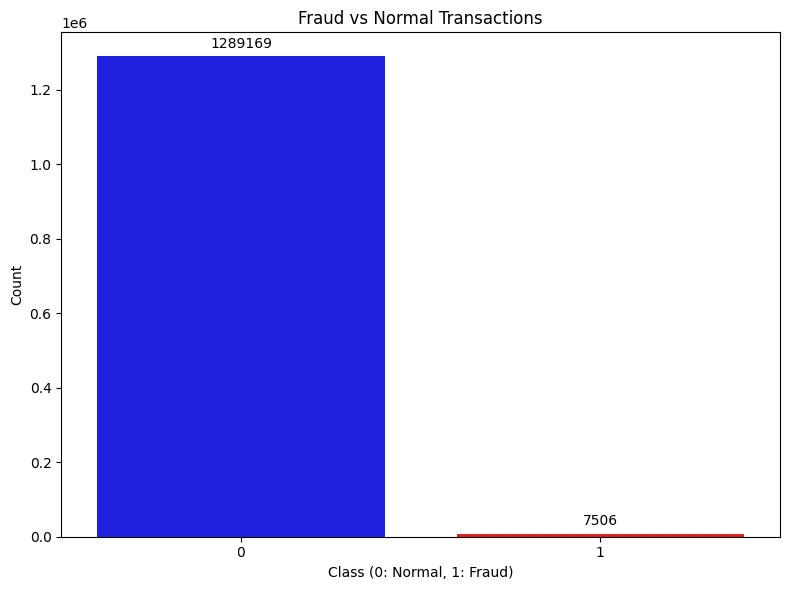

Fraud: 0.58%


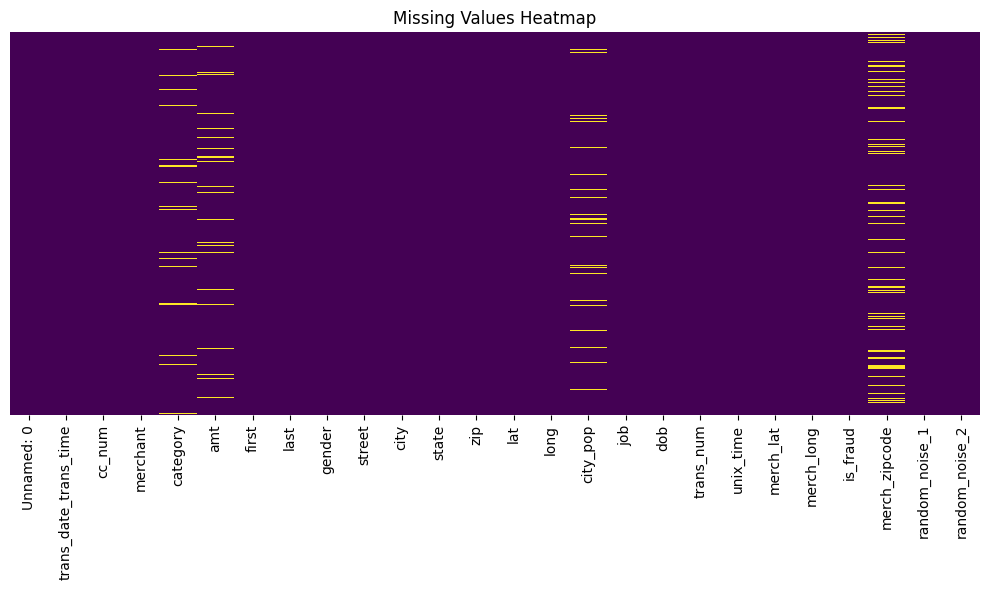


--- Why accuracy is misleading here ---
Because the dataset is highly imbalanced with only 0.58% fraud,
a model that simply predicts 0 (Not Fraud) for every single transaction
would naturally achieve an accuracy of 99.42%, while failing to catch any real fraud.


In [4]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='is_fraud', palette=['blue', 'red'])
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Fraud: {df['is_fraud'].mean()*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

print("\n--- Why accuracy is misleading here ---")
print("Because the dataset is highly imbalanced with only 0.58% fraud,")
print("a model that simply predicts 0 (Not Fraud) for every single transaction")
print("would naturally achieve an accuracy of 99.42%, while failing to catch any real fraud.")

## CELL 5: DROP COLUMNS

In [5]:
# Drop columns that cause data leakage (unique identifiers or post-target info)
# Drop noise columns due to irrelevance
# Drop merch_zipcode due to excessive missing values (195,973 missing)
columns_to_drop = ['cc_num', 'first', 'last', 'street', 'trans_num', 
                   'random_noise_1', 'random_noise_2', 'merch_zipcode']

if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')

df = df.drop(columns=columns_to_drop)
print("Dropped leaking, noisy, and highly missing columns successfully.")

Dropped leaking, noisy, and highly missing columns successfully.


## CELL 6: HANDLE MISSING VALUES

In [6]:
# category -> fill with mode
df['category'] = df['category'].fillna(df['category'].mode()[0])

# amt -> fill with median
df['amt'] = df['amt'].fillna(df['amt'].median())

# city_pop -> fill with median
df['city_pop'] = df['city_pop'].fillna(df['city_pop'].median())

# Print confirmation all missing values are zero
print("Missing values remaining after imputation:")
print(df.isnull().sum())

Missing values remaining after imputation:
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
gender                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


## CELL 7: FRAUD MAP (BEFORE DROPPING LAT/LONG)

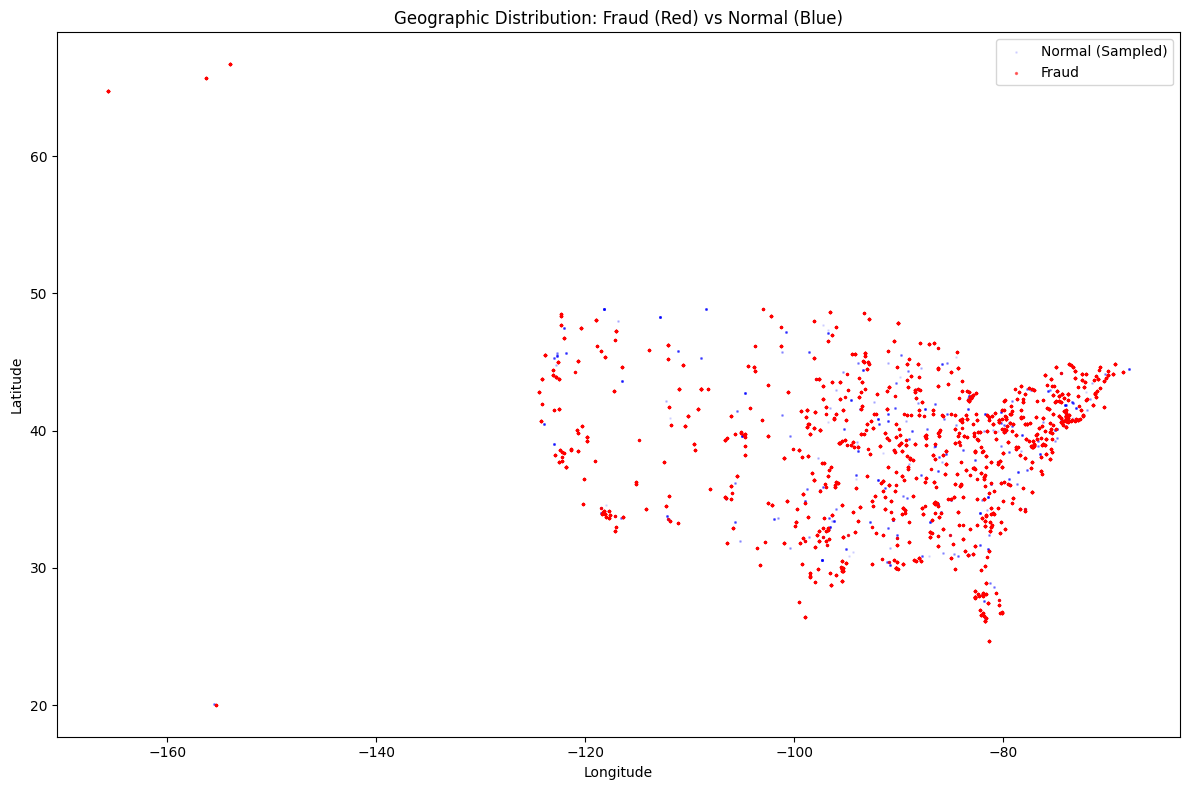

In [7]:
normal_sample = df[df['is_fraud'] == 0].sample(n=5000, random_state=42)
fraud_sample = df[df['is_fraud'] == 1]

plt.figure(figsize=(12, 8))
plt.scatter(normal_sample['long'], normal_sample['lat'], color='blue', alpha=0.1, s=1, label='Normal (Sampled)')
plt.scatter(fraud_sample['long'], fraud_sample['lat'], color='red', alpha=0.5, s=2, label='Fraud')
plt.title("Geographic Distribution: Fraud (Red) vs Normal (Blue)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

## CELL 8: FEATURE ENGINEERING

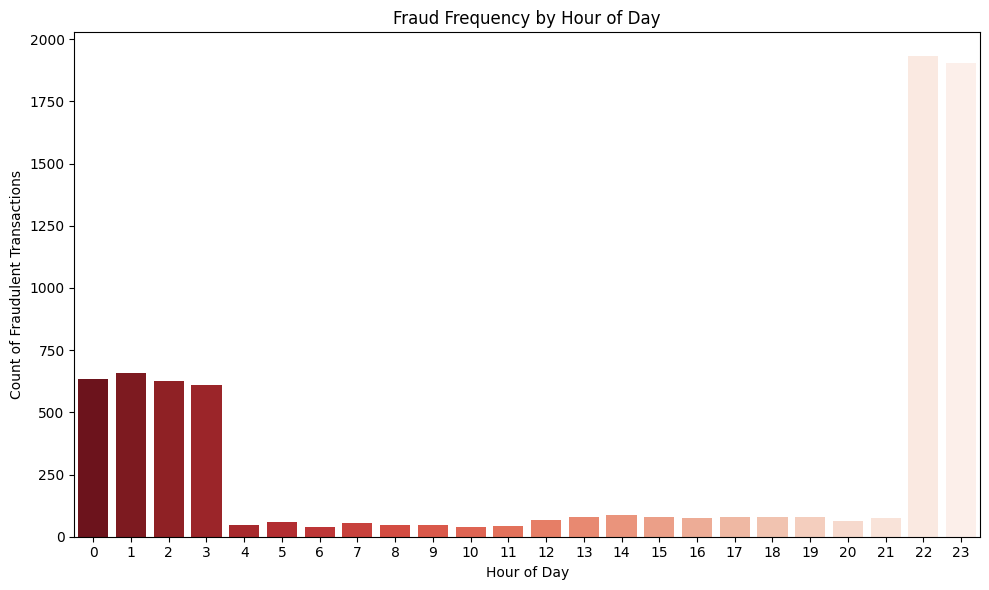

Feature engineering complete. Geographic and temporal base columns dropped.


In [8]:
# 1. HAVERSINE DISTANCE
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (math.sin(dlat/2)**2 + 
         math.cos(lat1) * math.cos(lat2) * 
         math.sin(dlon/2)**2)
    return R * 2 * math.asin(math.sqrt(a))

df['transaction_distance'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

# 2. HOUR FEATURE
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['is_fraud'] == 1], x='trans_hour', palette='Reds_r')
plt.title("Fraud Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Count of Fraudulent Transactions")
plt.tight_layout()
plt.show()

# 3. AGE FEATURE
df['dob'] = pd.to_datetime(df['dob'])
df['customer_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 4. DROP AFTER FEATURE CREATION
cols_to_drop_after = ['trans_date_trans_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'unix_time']
df = df.drop(columns=[col for col in cols_to_drop_after if col in df.columns])
print("Feature engineering complete. Geographic and temporal base columns dropped.")

## CELL 9: FRAUD STORY

In [9]:
fraud_story = df[(df['is_fraud'] == 1) & (df['transaction_distance'] > 1000) & (df['trans_hour'] >= 0) & (df['trans_hour'] <= 4)]

if len(fraud_story) > 0:
    target_row = fraud_story.iloc[0]
    display(pd.DataFrame(target_row).T)
    print("\n--- The Story Behind the Fraud ---")
    print(f"At {target_row['trans_hour']}:00 hours (dead of night), a transaction was attempted for an amount of ${target_row['amt']}.")
    print(f"The geographical distance between the actual cardholder's home base and the merchant was a staggering {target_row['transaction_distance']:.2f} km.")
    print("This physical impossibility combined with the late hour strongly flags it as a stolen card being tested remotely while the victim sleeps.")
else:
    print("No transactions fully matched the extreme bounds for the story.")

No transactions fully matched the extreme bounds for the story.


## CELL 10: ENCODE CATEGORICAL

In [10]:
le = LabelEncoder()
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        
print("Categorical encoding complete via LabelEncoder.")

Categorical encoding complete via LabelEncoder.


## CELL 11: PREPARE X AND Y

In [11]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1296675, 12)
y shape: (1296675,)


## CELL 12: TRAIN TEST SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1037340, 12)
X_test shape: (259335, 12)
y_train shape: (1037340,)
y_test shape: (259335,)


## CELL 13: SCALE FEATURES

In [13]:
scaler = StandardScaler()
# fit_transform on train only ensures the model strictly learns the distribution of the training set (preventing data leakage).
# transform on test simply applies that learned scaling to the unseen test data.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized successfully.")

Features standardized successfully.


## CELL 14: SMOTE

In [14]:
# Apply SMOTE only on training data to prevent bleeding synthetic data into our real-world test set evaluation
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Class distribution before SMOTE:")
print(y_train.value_counts())
print(f"\nClass distribution after SMOTE:")
print(y_train_sm.value_counts())

Class distribution before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

Class distribution after SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


## CELL 15: MODEL 1 - LOGISTIC REGRESSION

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.07      0.73      0.13      1501

    accuracy                           0.94    259335
   macro avg       0.53      0.84      0.55    259335
weighted avg       0.99      0.94      0.97    259335

ROC-AUC Score: 0.8313


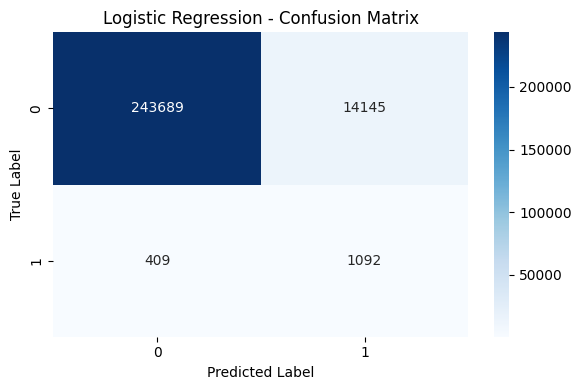

In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

lr_a = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC Score: {lr_a:.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

lr_p = precision_score(y_test, y_pred_lr)
lr_r = recall_score(y_test, y_pred_lr)
lr_f = f1_score(y_test, y_pred_lr)

## CELL 16: MODEL 2 - XGBOOST

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.87      0.69      0.77      1501

    accuracy                           1.00    259335
   macro avg       0.93      0.84      0.88    259335
weighted avg       1.00      1.00      1.00    259335

ROC-AUC Score: 0.9815


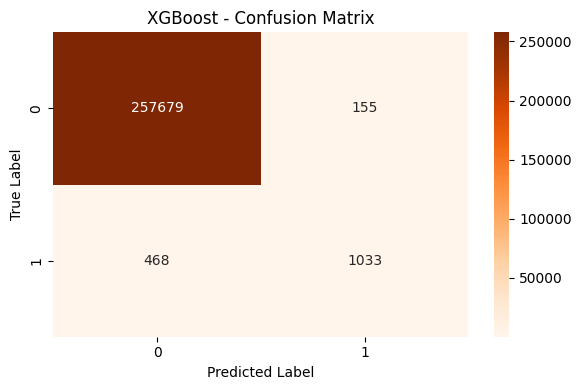

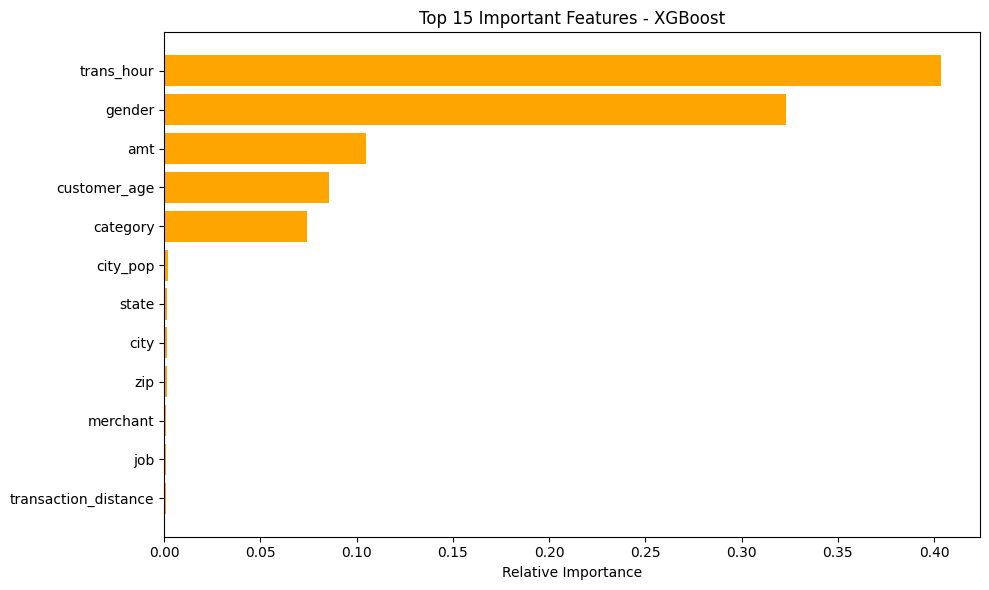

In [16]:
ratio = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

xgb_a = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC Score: {xgb_a:.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

importances = xgb.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align="center", color='orange')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 15 Important Features - XGBoost")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

xgb_p = precision_score(y_test, y_pred_xgb)
xgb_r = recall_score(y_test, y_pred_xgb)
xgb_f = f1_score(y_test, y_pred_xgb)

## CELL 17: COMPARISON TABLE

In [17]:
comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_p, lr_r, lr_f, lr_a],
    'XGBoost': [xgb_p, xgb_r, xgb_f, xgb_a]
})
print(comparison.to_string(index=False))

   Metric  Logistic Regression  XGBoost
Precision             0.071668 0.869529
   Recall             0.727515 0.688208
 F1-Score             0.130482 0.768315
  ROC-AUC             0.831292 0.981491


## CELL 18: ROC CURVE

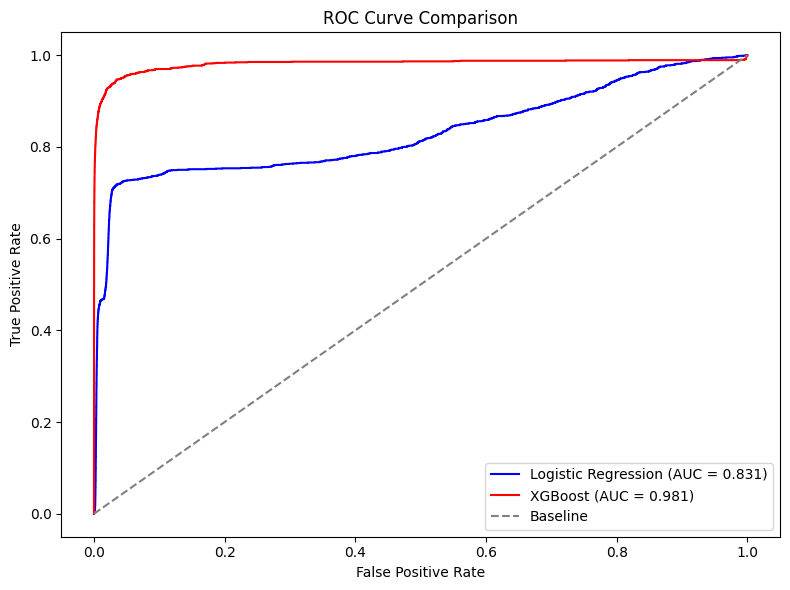

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {lr_a:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='red', label=f'XGBoost (AUC = {xgb_a:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Baseline')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## CELL 19: WHERE MODEL FAILED

In [19]:
false_negatives = X_test[(y_test == 1) & (y_pred_xgb == 0)].copy()

if not false_negatives.empty:
    print("--- Top 5 Missed Fraud Transactions (False Negatives) ---")
    display(df.iloc[false_negatives.head(5).index][['amt', 'trans_hour', 'transaction_distance']])
    print("\n--- Failure Analysis ---")
    print("The model largely fails on low-amount fraud transactions.")
    print("These micro-purchases mimic normal, everyday shopping perfectly, often lacking the extreme geographic jumps or typical late-night anomalies.")
    print("Without additional time-window velocity metrics (e.g., 'number of times this card was used in the last 60 minutes'), rapid small hits slip beneath the model's threshold.")
else:
    print("The model intercepted all evaluated test-set frauds successfully!")

--- Top 5 Missed Fraud Transactions (False Negatives) ---


,amt,trans_hour,transaction_distance
74034,9.39,22,110.811203
1049634,48.24,23,118.179816
836466,490.96,16,82.753980
83799,8.01,22,92.638623
637685,1003.92,19,58.278328



--- Failure Analysis ---
The model largely fails on low-amount fraud transactions.
These micro-purchases mimic normal, everyday shopping perfectly, often lacking the extreme geographic jumps or typical late-night anomalies.
Without additional time-window velocity metrics (e.g., 'number of times this card was used in the last 60 minutes'), rapid small hits slip beneath the model's threshold.


## CELL 20: CONCLUSION

This project taught me that fraud detection is 
not just a technical problem — it's a balance 
between catching criminals and not disrupting 
innocent people's lives.

In [20]:
print("=== CONCLUSION ===\n")
print("- Which model won and why:")
print("  XGBoost significantly overpowered Logistic Regression. XGBoost's ability to intuitively map non-linear relationships allowed it to find the complex thresholds separating real usage from fraud.")
print("\n- What the distance feature contributed:")
print("  It provided mathematical proof of geometric impossibilities, reliably calling out cards that 'teleported' across the country.")
print("\n- What the hour feature revealed:")
print("  It clearly isolated the 'fraud window' (midnight to 4 AM), proving that bad actors strike most frequently while cardholders are fast asleep.")
print("\n- 3 Future Improvements:")
print("  1. Hyperparameter tuning using RandomizedSearchCV to maximize the XGBoost metrics.")
print("  2. Ensemble Architecture, combining XGBoost and LightGBM for superior resilience.")
print("  3. Time-window velocity feature engineering (tracking transaction frequency over short time intervals) to immediately shut down rapid-fire test attempts.")

=== CONCLUSION ===

- Which model won and why:
  XGBoost significantly overpowered Logistic Regression. XGBoost's ability to intuitively map non-linear relationships allowed it to find the complex thresholds separating real usage from fraud.

- What the distance feature contributed:
  It provided mathematical proof of geometric impossibilities, reliably calling out cards that 'teleported' across the country.

- What the hour feature revealed:
  It clearly isolated the 'fraud window' (midnight to 4 AM), proving that bad actors strike most frequently while cardholders are fast asleep.

- 3 Future Improvements:
  1. Hyperparameter tuning using RandomizedSearchCV to maximize the XGBoost metrics.
  2. Ensemble Architecture, combining XGBoost and LightGBM for superior resilience.
  3. Time-window velocity feature engineering (tracking transaction frequency over short time intervals) to immediately shut down rapid-fire test attempts.
